## 1. Kurulum ve Bağımlılıklar

## ⚙️ Konfigürasyon — Sadece bu hücreyi değiştir!
Farklı bir branch veya dataset için **yalnızca aşağıdaki hücreyi** güncelle. Geri kalan tüm hücreler buradan okur.
Model seçimi için serbest string yerine `MODEL_PRESET_KEY` kullanılır: `bert`, `bio-bert`, `roberta`.
Yeni eğitim davranışı için bu hücrede özellikle `USE_NOISING_F` ve `PRE_ANSWER_LOSS_WEIGHT` alanlarını kontrol et.


In [118]:
# ============================================================
# PROJE KONFİGÜRASYONU — Branch değiştirince sadece burayı güncelle
# ============================================================

import os

# --- GitHub & Drive ---
REPO_URL        = "https://github.com/panzerofthelake03/DiffuVQA.git"
BRANCH          = "Bio-Bert"
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/DiffuVQA"
LOCAL_CLONE_PATH   = "/content/DiffuVQA"

# --- Model preset seçimi ---
MODEL_PRESETS = {
    "bert": {
        "model_slug": "bert",
        "model_label": "DiffuVQA-BERT",
        "model_arch": "transformer-bert",
        "vocab": "bert",
        "config_name": "bert-base-uncased",
        "use_plm_init": "bert",
    },
    "bio-bert": {
        "model_slug": "bio-bert",
        "model_label": "DiffuVQA-BioBERT",
        "model_arch": "transformer-bio-bert",
        "vocab": "bio-bert",
        "config_name": "dmis-lab/biobert-v1.1",
        "use_plm_init": "bert",
    },
    "roberta": {
        "model_slug": "roberta",
        "model_label": "DiffuVQA-RoBERTa",
        "model_arch": "transformer-roberta",
        "vocab": "roberta",
        "config_name": "roberta-large",
        "use_plm_init": "roberta",
    },
}

MODEL_PRESET_KEY = "bio-bert"  # seçenekler: bert, bio-bert, roberta
if MODEL_PRESET_KEY not in MODEL_PRESETS:
    raise ValueError(f"Geçersiz MODEL_PRESET_KEY: {MODEL_PRESET_KEY}. Kullanılabilir değerler: {sorted(MODEL_PRESETS)}")

MODEL_PRESET = MODEL_PRESETS[MODEL_PRESET_KEY]
MODEL_NAME = MODEL_PRESET_KEY
MODEL_SLUG = MODEL_PRESET["model_slug"]
MODEL_LABEL = MODEL_PRESET["model_label"]
MODEL_ARCH = MODEL_PRESET["model_arch"]
VOCAB_NAME = MODEL_PRESET["vocab"]
CONFIG_NAME = MODEL_PRESET["config_name"]
USE_PLM_INIT = MODEL_PRESET["use_plm_init"]

# --- Dataset ---
DATASET         = "SLAKE"             # "SLAKE", "Kvasir_VQA", "daveKevin" vb.
DATA_DIR        = "datasets"
IMAGEFOLDER_NAME = "SLAKE"
DRIVE_IMAGE_DIR = f"{DRIVE_PROJECT_PATH}/datasets/{IMAGEFOLDER_NAME}/imgs" # daveKevin_images , SLAKE
LOCAL_IMAGE_DIR = f"{LOCAL_CLONE_PATH}/datasets/{IMAGEFOLDER_NAME}/imgs" # daveKevin_images , SLAKE

# Drive'daki dataset görüntü klasörü (birden fazla olası yol)
DATASET_IMG_PATHS = [
    f"/content/drive/MyDrive/datasets/{DATASET}/imgs/imgs",
    f"/content/drive/MyDrive/{DATASET}_dataset/imgs",
    f"/content/drive/Drive'ım/{DATASET}_dataset/imgs",
    f"/content/drive/MyDrive/{DATASET}/imgs",
    f"/content/drive/Drive'ım/{DATASET}/imgs",
]

# --- Eğitim ---
BATCH_SIZE      = 64
MICROBATCH      = 16
LR              = 0.00005
LEARNING_STEPS  = 0
TARGET_TOTAL_STEPS = 300000  # Resume sonrası ulaşılacak toplam global step
DIFFUSION_STEPS = 200
SEQ_LEN         = 32
HIDDEN_T_DIM    = 768
SEED            = 42
SAVE_INTERVAL   = 2000
LOG_INTERVAL    = 100
EVAL_INTERVAL   = 500

# Training objective controls
USE_NOISING_F = False
PRE_ANSWER_LOSS_WEIGHT = 0.0

# --- Checkpoint & Çıktı ---
CHECKPOINT_PATH = f"/content/drive/MyDrive/DiffuVQA/checkpoints/{DATASET.lower()}/{MODEL_SLUG}/btch{BATCH_SIZE}/lr{LR}"
SAMPLE_FOLDER   = f"/content/drive/MyDrive/DiffuVQA/samples/{DATASET.lower()}/{MODEL_SLUG}"
OUTPUT_CSV      = f"./reports/{MODEL_SLUG}_{DATASET.lower()}_evaluation_results.csv"
DRIVE_RESULTS_PATH = "/content/drive/MyDrive/DiffuVQA_Results/"

# --- Resume ---
RESUME_CHECKPOINT = "none" #f"{CHECKPOINT_PATH}/ema_0.9999_{LEARNING_STEPS:06d}.pt"  # örn: f"{CHECKPOINT_PATH}/ema_0.9999_009800.pt"

print("✅ Konfigürasyon yüklendi:")
print(f"   Branch      : {BRANCH}  →  {REPO_URL}")
print(f"   ModelPreset : {MODEL_PRESET_KEY}")
print(f"   ModelArch   : {MODEL_ARCH}")
print(f"   Vocab       : {VOCAB_NAME}")
print(f"   Config      : {CONFIG_NAME}")
print(f"   Dataset     : {DATASET}")
print(f"   Checkpoint  : {CHECKPOINT_PATH}")
print(f"   TargetStep  : {TARGET_TOTAL_STEPS}")
print(f"   ResumeFrom  : {RESUME_CHECKPOINT}")
print(f"   use_noising_f          : {USE_NOISING_F}")
print(f"   pre_answer_loss_weight : {PRE_ANSWER_LOSS_WEIGHT}")

✅ Konfigürasyon yüklendi:
   Branch      : Bio-Bert  →  https://github.com/panzerofthelake03/DiffuVQA.git
   ModelPreset : bio-bert
   ModelArch   : transformer-bio-bert
   Vocab       : bio-bert
   Config      : dmis-lab/biobert-v1.1
   Dataset     : SLAKE
   Checkpoint  : /content/drive/MyDrive/DiffuVQA/checkpoints/slake/bio-bert/btch64/lr0.000283
   TargetStep  : 300000
   ResumeFrom  : none
   use_noising_f          : False
   pre_answer_loss_weight : 0.0


In [119]:
# GPU kontrolü
!nvidia-smi

Mon May 11 19:23:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             48W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [120]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [121]:
import os
import shutil

# ADIM 1: Colab'daki geçici klasörü temizle (Taze indirme için şart)
if os.path.exists(LOCAL_CLONE_PATH):
    print(f"Eski geçici klasör siliniyor: {LOCAL_CLONE_PATH}")
    shutil.rmtree(LOCAL_CLONE_PATH)

# ADIM 2: GitHub'dan en güncel hali çek
print("GitHub'dan taze kopya çekiliyor...")
!git clone -b {BRANCH} --single-branch {REPO_URL} {LOCAL_CLONE_PATH}

# ADIM 3: Drive'ı GÜNCELLE (dirs_exist_ok=True ile klasör olsa bile içine girip dosyaları yeniler)
print(f"Drive'daki dosyalar güncelleniyor: {DRIVE_PROJECT_PATH}")
if not os.path.exists(DRIVE_PROJECT_PATH):
    os.makedirs(DRIVE_PROJECT_PATH)

shutil.copytree(LOCAL_CLONE_PATH, DRIVE_PROJECT_PATH, dirs_exist_ok=True)
print("\n✅ İŞLEM TAMAM: Yeni dosyalar Drive'a geçti!")

# Çalışma dizinini Drive'daki projeye ayarla
os.chdir(DRIVE_PROJECT_PATH)
print(f"📂 Çalışma dizini: {os.getcwd()}")


Eski geçici klasör siliniyor: /content/DiffuVQA
GitHub'dan taze kopya çekiliyor...
Cloning into '/content/DiffuVQA'...
remote: Enumerating objects: 1176, done.
remote: Counting objects: 100% (380/380), done.
remote: Compressing objects: 100% (136/136), done.
remote: Total 1176 (delta 306), reused 263 (delta 244), pack-reused 796 (from 2)
Receiving objects: 100% (1176/1176), 114.34 MiB | 18.63 MiB/s, done.
Resolving deltas: 100% (602/602), done.
Updating files: 100% (484/484), done.
Drive'daki dosyalar güncelleniyor: /content/drive/MyDrive/DiffuVQA

✅ İŞLEM TAMAM: Yeni dosyalar Drive'a geçti!
📂 Çalışma dizini: /content/drive/MyDrive/DiffuVQA


In [122]:
# Mevcut bir Drive klonu varsa sadece güncelle (clone yerine alternatif)
if os.path.exists(DRIVE_PROJECT_PATH):
    os.chdir(DRIVE_PROJECT_PATH)
    print(f"📂 Çalışma dizini değiştirildi: {os.getcwd()}")
    print("⬇️ GitHub'dan güncellemeler çekiliyor (git pull)...")
    !git pull
    print("\n✅ Güncelleme tamamlandı. İşte son 3 değişiklik:")
    !git log -3 --oneline
else:
    print("❌ Hata: Drive'da proje klasörü bulunamadı. Önce yukarıdaki clone hücresini çalıştır.")


📂 Çalışma dizini değiştirildi: /content/drive/MyDrive/DiffuVQA
⬇️ GitHub'dan güncellemeler çekiliyor (git pull)...
Already up to date.

✅ Güncelleme tamamlandı. İşte son 3 değişiklik:
f4e272a8 (HEAD -> Bio-Bert, origin/Bio-Bert) Merge branch 'Bio-Bert' of https://github.com/panzerofthelake03/DiffuVQA into Bio-Bert
5a8c25ac Noise fix
20b554ea Colab kullanılarak oluşturuldu


In [123]:
import os
import shutil
from tqdm.auto import tqdm

# Resolve the first existing path from a list of candidates.
def resolve_dataset_image_source(candidate_paths):
    seen = set()
    for path in candidate_paths:
        if not path or not isinstance(path, str):
            continue
        norm = os.path.normpath(path)
        if norm in seen:
            continue
        seen.add(norm)
        if os.path.exists(path):
            return path
    return None

# Build dataset-local destination from Cell 1 configuration.
dataset_local_root = os.path.join(LOCAL_CLONE_PATH, DATA_DIR, IMAGEFOLDER_NAME)
dataset_local_imgs = os.path.join(dataset_local_root, "imgs")

# Candidate sources in priority order: local config -> DRIVE_IMAGE_DIR -> other dataset candidates.
source_candidates = [
    LOCAL_IMAGE_DIR,
    DRIVE_IMAGE_DIR,
    *DATASET_IMG_PATHS,
    os.path.join(DRIVE_PROJECT_PATH, DATA_DIR, IMAGEFOLDER_NAME, "imgs"),
    os.path.join(DRIVE_PROJECT_PATH, DATA_DIR, DATASET, "imgs"),
]
source_image_path = resolve_dataset_image_source(source_candidates)

# Default active dir for downstream cells.
ACTIVE_IMAGE_DIR = dataset_local_imgs if os.path.exists(dataset_local_imgs) else dataset_local_root

print("Dataset image source candidates:")
for p in source_candidates:
    print(f"  - {p}")

if source_image_path:
    print(f"Using source image path: {source_image_path}")

    src_abs = os.path.abspath(source_image_path)
    dst_abs = os.path.abspath(dataset_local_imgs)

    # Copy files into the local runtime location when source is external.
    if src_abs != dst_abs:
        os.makedirs(dataset_local_imgs, exist_ok=True)

        files_to_copy = []
        for root, _, files in os.walk(source_image_path):
            for file_name in files:
                src_file = os.path.join(root, file_name)
                rel_path = os.path.relpath(src_file, source_image_path)
                dst_file = os.path.join(dataset_local_imgs, rel_path)
                files_to_copy.append((src_file, dst_file))

        for src_file, dst_file in tqdm(files_to_copy, desc="Copying dataset images", unit="file"):
            os.makedirs(os.path.dirname(dst_file), exist_ok=True)
            shutil.copy2(src_file, dst_file)

        print(f"Copied {len(files_to_copy)} files into: {dataset_local_imgs}")
    else:
        print("Source already points to local runtime image directory; skipping copy.")
else:
    print("No configured source image path found; using existing local dataset directory if present.")

# Final active image dir selection for all downstream cells.
if os.path.exists(dataset_local_imgs):
    ACTIVE_IMAGE_DIR = dataset_local_imgs
elif os.path.exists(dataset_local_root):
    ACTIVE_IMAGE_DIR = dataset_local_root
elif source_image_path and os.path.exists(source_image_path):
    ACTIVE_IMAGE_DIR = source_image_path

print(f"ACTIVE_IMAGE_DIR set to: {ACTIVE_IMAGE_DIR}")

Dataset image source candidates:
  - /content/DiffuVQA/datasets/SLAKE/imgs
  - /content/drive/MyDrive/DiffuVQA/datasets/SLAKE/imgs
  - /content/drive/MyDrive/datasets/SLAKE/imgs/imgs
  - /content/drive/MyDrive/SLAKE_dataset/imgs
  - /content/drive/Drive'ım/SLAKE_dataset/imgs
  - /content/drive/MyDrive/SLAKE/imgs
  - /content/drive/Drive'ım/SLAKE/imgs
  - /content/drive/MyDrive/DiffuVQA/datasets/SLAKE/imgs
  - /content/drive/MyDrive/DiffuVQA/datasets/SLAKE/imgs
Using source image path: /content/drive/MyDrive/DiffuVQA/datasets/SLAKE/imgs


Copying dataset images:   0%|          | 0/2592 [00:00<?, ?file/s]

Copied 2592 files into: /content/DiffuVQA/datasets/SLAKE/imgs
ACTIVE_IMAGE_DIR set to: /content/DiffuVQA/datasets/SLAKE/imgs


In [124]:
# Dataset yapısını kontrol et
import os

active_image_dir = ACTIVE_IMAGE_DIR if "ACTIVE_IMAGE_DIR" in globals() else LOCAL_IMAGE_DIR

!echo "📂 Dataset klasörü:"
!ls -lh datasets/
!echo "\n📊 JSONL dosyaları:"
!ls -lh datasets/*.jsonl
print(f"\n🖼️ Active image dir: {active_image_dir}")
if os.path.exists(active_image_dir):
    try:
        print("İlk 5 dosya:")
        for i, name in enumerate(sorted(os.listdir(active_image_dir))[:5], 1):
            print(f"  {i}. {name}")
    except Exception as e:
        print(f"⚠️ Image dir listelenemedi: {e}")
else:
    print("⚠️ Active image dir bulunamadı.")

!echo "\n📄 Train set örneği:"
!head -n 1 datasets/train.jsonl


📂 Dataset klasörü:
total 3.4M
drwx------ 2 root root 4.0K Dec 17 20:24 daveKevin_images
-rw------- 1 root root 132K Mar  2 10:01 daveKevin_samples_test.png
-rw------- 1 root root 158K Mar  2 14:18 daveKevin_samples_train.png
-rw------- 1 root root 179K Mar  2 14:19 daveKevin_samples_valid.png
-rw------- 1 root root 136K Mar 11 22:42 daveKevin_test_first3_preview.png
-rw------- 1 root root 149K May  6 00:48 daveKevin_train_first3_preview.png
-rw------- 1 root root 174K Apr 19 18:21 daveKevin_valid_first3_preview.png
drwx------ 3 root root 4.0K Mar  5 10:12 SLAKE
-rw------- 1 root root 170K May 11 19:05 SLAKE_test_first3_preview.png
-rw------- 1 root root 107K May 11 19:19 SLAKE_train_first3_preview.png
-rw------- 1 root root 100K May 11 19:19 SLAKE_valid_first3_preview.png
-rw------- 1 root root 324K May 11 19:23 test.jsonl
-rw------- 1 root root 1.5M May 11 19:23 train.jsonl
-rw------- 1 root root 322K May 11 19:23 valid.jsonl
\n📊 JSONL dosyaları:
-rw------- 1 root root 324K May 11 19:

Searching for images in: /content/DiffuVQA/datasets/SLAKE/imgs
Found 1289 images.


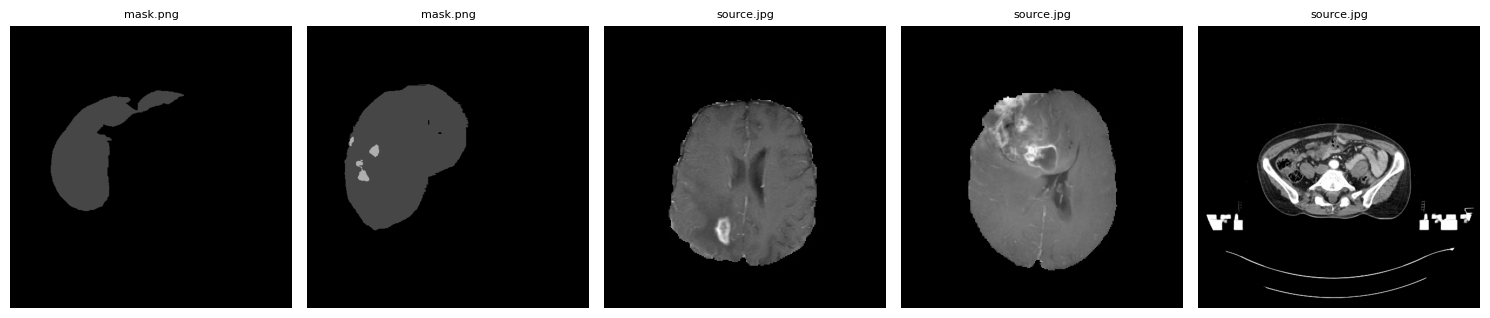

✅ Displayed 5 example images.


In [125]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

# Use dataset-agnostic active image dir prepared in previous cell.
image_folder_path = ACTIVE_IMAGE_DIR if "ACTIVE_IMAGE_DIR" in globals() else LOCAL_IMAGE_DIR
print(f"Searching for images in: {image_folder_path}")

image_extensions = (".png", ".jpg", ".jpeg", ".gif", ".bmp", ".tiff")
all_image_files = []
for root, _, files in os.walk(image_folder_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            all_image_files.append(os.path.join(root, file))

if not all_image_files:
    print(f"⚠️ No images found in {image_folder_path}. Please check path/config.")
else:
    print(f"Found {len(all_image_files)} images.")
    num_examples = min(5, len(all_image_files))
    selected_images = random.sample(all_image_files, num_examples)

    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(selected_images):
        try:
            img = Image.open(img_path)
            plt.subplot(1, num_examples, i + 1)
            plt.imshow(img)
            plt.title(os.path.basename(img_path), fontsize=8)
            plt.axis("off")
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            plt.subplot(1, num_examples, i + 1)
            plt.text(0.5, 0.5, "Error", horizontalalignment="center", verticalalignment="center", transform=plt.gca().transAxes, color="red")
            plt.axis("off")

    plt.tight_layout()
    plt.show()
    print(f"✅ Displayed {num_examples} example images.")

In [126]:
# vqa_datasets __main__ test (runs the module exactly like a script)
import os
import sys
import subprocess

# Ensure we run from project root
os.chdir(DRIVE_PROJECT_PATH)
print(f"cwd: {os.getcwd()}")

# Use dataset-agnostic image dir
data_dir = DATA_DIR
image_dir = ACTIVE_IMAGE_DIR if "ACTIVE_IMAGE_DIR" in globals() else LOCAL_IMAGE_DIR
dataset_name = DATASET

cmd = [
    sys.executable,
    "-m",
    "diffuvqa.vqa_datasets",
    "--data_dir", data_dir,
    "--dataset", dataset_name,
    "--image_dir", image_dir,
    "--vocab", VOCAB_NAME,
    "--config_name", CONFIG_NAME,
    "--batch_size", "1",
    "--seq_len", "64",
    "--image_size", "224",
]

print("Running command:")
print(" ".join(cmd))
print("-" * 80)

result = subprocess.run(cmd, text=True, capture_output=True)
print(result.stdout)
if result.stderr:
    print("[stderr]")
    print(result.stderr)

print("-" * 80)
print(f"Return code: {result.returncode}")
if result.returncode != 0:
    print("vqa_datasets __main__ test failed. Check logs above for missing path/dependency details.")
else:
    print("vqa_datasets __main__ test completed successfully.")

cwd: /content/drive/MyDrive/DiffuVQA
Running command:
/usr/bin/python3 -m diffuvqa.vqa_datasets --data_dir datasets --dataset SLAKE --image_dir /content/DiffuVQA/datasets/SLAKE/imgs --vocab bio-bert --config_name dmis-lab/biobert-v1.1 --batch_size 1 --seq_len 64 --image_size 224
--------------------------------------------------------------------------------
save tokenizer to diffuvqa/config
reload the random embeddings Embedding(28996, 1024)
  Old checkpoint vocab size likely doesn't match current tokenizer
  Current tokenizer vocab size: 28996
  Saved new embeddings to diffuvqa/config/random_emb.torch
Logging to /tmp/openai-2026-05-11-19-23-41-471947
##############################
Loading text data...
##############################
Loading dataset SLAKE from datasets...
### Loading from the TRAIN set...
### Data samples...
questions: ['What modality is used to take this image?', 'Which part of the body does this image belong to?'] answers: ['MRI', 'Abdomen'] images: ['imgs/xmlab1/sou

In [127]:
# Bağımlılıkları yükle
# Colab PyTorch ile geliyor, o yüzden requirements_colab.txt kullanıyoruz
!pip install --upgrade pip
!pip install -r requirements_colab.txt
!pip install pandas openpyxl bert-score  # Excel support ve BERTScore için
!python -m spacy download en_core_web_sm

print("\n✅ Kurulum tamamlandı!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 161.5 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

✅ Kurulum tamamlandı!


In [128]:
# Gerekli kütüphaneleri içe aktar
import os
import sys
import json
import torch
import pandas as pd
import numpy as np
from datetime import datetime
from collections import defaultdict
import glob

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
!pip install torchmetrics

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device: NVIDIA A100-SXM4-40GB


## 2. Model Eğitimi


In [129]:
import os
import json
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

train_image_dir = ACTIVE_IMAGE_DIR if "ACTIVE_IMAGE_DIR" in globals() else LOCAL_IMAGE_DIR
target_steps = TARGET_TOTAL_STEPS if "TARGET_TOTAL_STEPS" in globals() else LEARNING_STEPS
resume_ckpt = RESUME_CHECKPOINT if "RESUME_CHECKPOINT" in globals() else "none"

print(f"Training with image_dir: {train_image_dir}")
print(f"Model preset: {MODEL_PRESET_KEY}")
print(f"Model arch: {MODEL_ARCH}")
print(f"Vocab: {VOCAB_NAME}")
print(f"Config: {CONFIG_NAME}")
print(f"Target total steps: {target_steps}")
print(f"Resume checkpoint: {resume_ckpt}")
print(f"use_noising_f: {USE_NOISING_F}")
print(f"pre_answer_loss_weight: {PRE_ANSWER_LOSS_WEIGHT}")

# Resume checkpoint ile mevcut runtime ayarlarının uyumluluğunu doğrula.
if resume_ckpt and resume_ckpt != "none":
    if not os.path.exists(resume_ckpt):
        raise FileNotFoundError(f"Resume checkpoint bulunamadı: {resume_ckpt}")

    resume_cfg = os.path.join(os.path.dirname(resume_ckpt), "training_args.json")
    if not os.path.exists(resume_cfg):
        raise FileNotFoundError(
            f"Resume checkpoint klasöründe training_args.json bulunamadı: {resume_cfg}"
        )

    with open(resume_cfg, "r", encoding="utf-8") as f:
        old_args = json.load(f)

    expected = {
        "model": MODEL_ARCH,
        "vocab": VOCAB_NAME,
        "config_name": CONFIG_NAME,
        "use_plm_init": USE_PLM_INIT,
        "hidden_t_dim": HIDDEN_T_DIM,
        "seq_len": SEQ_LEN,
        "diffusion_steps": DIFFUSION_STEPS,
        "use_noising_f": USE_NOISING_F,
        "pre_answer_loss_weight": PRE_ANSWER_LOSS_WEIGHT,
    }

    mismatches = []
    for key, new_val in expected.items():
        old_val = old_args.get(key)
        if old_val != new_val:
            mismatches.append((key, old_val, new_val))

    if mismatches:
        detail = "\n".join([
            f"- {k}: checkpoint={ov} | current={nv}" for k, ov, nv in mismatches
        ])
        raise ValueError(
            "Resume checkpoint ayarları mevcut eğitim ayarlarıyla uyuşmuyor. "
            "Özellikle training objective değiştiyse eski checkpoint ile doğrudan devam etmek doğru değildir. "
            "Bu checkpoint ile devam etmek için ayarları eşitle veya RESUME_CHECKPOINT='none' yap.\n"
            + detail
        )

    print("✅ Resume checkpoint ayarları doğrulandı")

!python train.py \
    --model {MODEL_ARCH} \
    --vocab {VOCAB_NAME} \
    --use_plm_init {USE_PLM_INIT} \
    --config_name {CONFIG_NAME} \
    --batch_size {BATCH_SIZE} \
    --microbatch {MICROBATCH} \
    --lr {LR} \
    --diffusion_steps {DIFFUSION_STEPS} \
    --seq_len {SEQ_LEN} \
    --hidden_t_dim {HIDDEN_T_DIM} \
    --checkpoint_path {CHECKPOINT_PATH} \
    --seed {SEED} \
    --learning_steps {target_steps} \
    --save_interval {SAVE_INTERVAL} \
    --log_interval {LOG_INTERVAL} \
    --eval_interval {EVAL_INTERVAL} \
    --resume_checkpoint {resume_ckpt} \
    --data_dir {DATA_DIR} \
    --dataset {DATASET} \
    --image_dir {train_image_dir} \
    --use_noising_f {USE_NOISING_F} \
    --pre_answer_loss_weight {PRE_ANSWER_LOSS_WEIGHT}

Training with image_dir: /content/DiffuVQA/datasets/SLAKE/imgs
Model preset: bio-bert
Model arch: transformer-bio-bert
Vocab: bio-bert
Config: dmis-lab/biobert-v1.1
Target total steps: 300000
Resume checkpoint: none
use_noising_f: False
pre_answer_loss_weight: 0.0
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 999, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/usr/local/lib/python3.12/dist-packages/datasets/download/__init__.py", line 9, in <module>
    from .download_manager import DownloadManager, DownloadMode
  File "/usr/local/lib/python3.12/dist-packages/datasets/download/download_manager.py", line 32, in <module>
    from ..utils.file_utils import (
  File "/usr/local/lib

## 3. Model Örnekleme (Inference)

### Sampling Smoke Test
Checkpoint varsa gerçek sampling çalışmadan önce mask ve diffusion davranışını doğrular.

In [130]:

# Sampling öncesi smoke test
import json
import os
import subprocess
import sys

os.chdir(DRIVE_PROJECT_PATH)

smoke_checkpoint = RESUME_CHECKPOINT if os.path.exists(RESUME_CHECKPOINT) else None
smoke_step = min(30, DIFFUSION_STEPS)
smoke_batch_size = min(2, BATCH_SIZE)

if smoke_checkpoint is None:
    print("ℹ️ Sampling smoke test atlandı: RESUME_CHECKPOINT bulunamadı.")
    print("   İlk kez eğitim yapıyorsan bu normal. Checkpoint oluştuktan sonra bu hücreyi çalıştır.")
else:
    smoke_cmd = [
        sys.executable,
        "scripts/smoke_test_sample_pipeline_behavior.py",
        "--checkpoint", smoke_checkpoint,
        "--split", "test",
        "--batch-size", str(smoke_batch_size),
        "--step", str(smoke_step),
        "--mask-mode", "patched",
    ]

    # Ensure the project root is on PYTHONPATH so `diffuvqa` is importable.
    smoke_env = os.environ.copy()
    existing_pypath = smoke_env.get("PYTHONPATH", "")
    smoke_env["PYTHONPATH"] = (
        DRIVE_PROJECT_PATH + os.pathsep + existing_pypath
        if existing_pypath
        else DRIVE_PROJECT_PATH
    )

    print("Running sampling smoke test:")
    print(" ".join(smoke_cmd))
    result = subprocess.run(smoke_cmd, text=True, capture_output=True, env=smoke_env)

    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print("[stderr]")
        print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError(f"Sampling smoke test başarısız oldu (return code={result.returncode})")

    report = json.loads(result.stdout)
    if not report.get("smoke_test_pass", False):
        raise RuntimeError(f"Sampling smoke test başarısız: {report}")

    print("✅ Sampling smoke test geçti")
    print(f"   checkpoint={report['checkpoint']}")
    print(f"   mask_behavior={report['mask_behavior']}")
    print(f"   noising_applied={report['noising_applied']}")
    print(f"   diffusion_changed_output={report['diffusion_changed_output']}")


ℹ️ Sampling smoke test atlandı: RESUME_CHECKPOINT bulunamadı.
   İlk kez eğitim yapıyorsan bu normal. Checkpoint oluştuktan sonra bu hücreyi çalıştır.


In [131]:
import glob
import os
import subprocess
import sys

# Test seti üzerinde örnekleme yap
SAMPLE_STEP = 25
SAMPLE_SEED2 = 102  # script output filename ile tutarlı


def choose_valid_checkpoint(preferred_path, checkpoint_dir):
    if preferred_path and os.path.exists(preferred_path):
        try:
            if os.path.getsize(preferred_path) > 0:
                return preferred_path, "preferred"
            print(f"⚠️ Boş checkpoint atlandı: {preferred_path}")
        except OSError:
            pass

    candidates = sorted(glob.glob(os.path.join(checkpoint_dir, "ema_*.pt")), reverse=True)
    for ckpt in candidates:
        try:
            if os.path.getsize(ckpt) > 0:
                return ckpt, "fallback_latest_nonempty"
            print(f"⚠️ Boş checkpoint atlandı: {ckpt}")
        except OSError:
            continue

    return None, "none"


# Önce LEARNING_STEPS checkpointini tercih et
preferred_checkpoint = os.path.join(CHECKPOINT_PATH, f"ema_0.9999_{LEARNING_STEPS:06d}.pt")
checkpoint_file, checkpoint_source = choose_valid_checkpoint(preferred_checkpoint, CHECKPOINT_PATH)

if checkpoint_file is None:
    raise FileNotFoundError(
        f"Geçerli (non-empty) checkpoint bulunamadı. Checkpoint klasörü: {CHECKPOINT_PATH}"
    )

print(f"📂 Kullanılacak checkpoint ({checkpoint_source}): {checkpoint_file}")

sample_cmd = [
    sys.executable,
    "sample_vqa_GPU.py",
    "--model_path", checkpoint_file,
    "--step", str(SAMPLE_STEP),
    "--batch_size", str(BATCH_SIZE),
    "--seed2", str(SAMPLE_SEED2),
    "--split", "test",
    "--out_dir", SAMPLE_FOLDER,
    "--clamp_step", "0",
]

print("Running sample command:")
print(" ".join(sample_cmd))
result = subprocess.run(sample_cmd, text=True, capture_output=True)

if result.stdout:
    print(result.stdout)
if result.stderr:
    print("[stderr]")
    print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        "Örnekleme başarısız oldu. "
        f"return_code={result.returncode}, checkpoint={checkpoint_file}"
    )

print("\n✅ Örnekleme tamamlandı!")
print(f"📂 Çıktı dosyaları {SAMPLE_FOLDER} klasöründe oluşturuldu.")

# Oluşturulan sample dosyasının adını kontrol et
base_checkpoint_name = os.path.basename(checkpoint_file)
expected_sample_filename = f"{base_checkpoint_name}.seed{SAMPLE_SEED2}_step0_samplestep{SAMPLE_STEP}_bsize{BATCH_SIZE}.jsonl"
expected_sample_filepath = os.path.join(SAMPLE_FOLDER, expected_sample_filename)

if os.path.exists(expected_sample_filepath):
    print("\n📄 Oluşturulan sample dosyası:")
    print(expected_sample_filepath)
else:
    print("⚠️ Beklenen sample dosyası bulunamadı. Klasördeki jsonl dosyaları:")
    for p in sorted(glob.glob(os.path.join(SAMPLE_FOLDER, "*.jsonl"))):
        print(f"  - {p}")

📂 Kullanılacak checkpoint (fallback_latest_nonempty): /content/drive/MyDrive/DiffuVQA/checkpoints/slake/bio-bert/btch64/lr0.000283/ema_0.9999_042000.pt
Running sample command:
/usr/bin/python3 sample_vqa_GPU.py --model_path /content/drive/MyDrive/DiffuVQA/checkpoints/slake/bio-bert/btch64/lr0.000283/ema_0.9999_042000.pt --step 25 --batch_size 64 --seed2 102 --split test --out_dir /content/drive/MyDrive/DiffuVQA/samples/slake/bio-bert --clamp_step 0
Logging to /tmp/openai-2026-05-11-19-24-17-621824
DEBUG: Parsed model_path = /content/drive/MyDrive/DiffuVQA/checkpoints/slake/bio-bert/btch64/lr0.000283/ema_0.9999_042000.pt
### Loading model from /content/drive/MyDrive/DiffuVQA/checkpoints/slake/bio-bert/btch64/lr0.000283/ema_0.9999_042000.pt
config_path: /content/drive/MyDrive/DiffuVQA/checkpoints/slake/bio-bert/btch64/lr0.000283/training_args.json
### Updated args: Namespace(model_path='/content/drive/MyDrive/DiffuVQA/checkpoints/slake/bio-bert/btch64/lr0.000283/ema_0.9999_042000.pt', st

RuntimeError: Örnekleme başarısız oldu. return_code=1, checkpoint=/content/drive/MyDrive/DiffuVQA/checkpoints/slake/bio-bert/btch64/lr0.000283/ema_0.9999_042000.pt

In [ ]:
# compare_image_black_vectors.py hızlı test hücresi (dataset-safe + import-safe + error-aware)
import glob
import os
import sys
import subprocess

# Komutu proje kökünden çalıştır ki `diffuvqa` import'u çözülsün
os.chdir(DRIVE_PROJECT_PATH)
print(f"📂 Çalışma dizini: {os.getcwd()}")

checkpoint_files = sorted(glob.glob(f"{CHECKPOINT_PATH}/ema_*.pt"))

if checkpoint_files:
    checkpoint_file = checkpoint_files[-1]
    print(f"📂 Vector karşılaştırma için checkpoint: {checkpoint_file}")
else:
    print("⚠️ Checkpoint bulunamadı. Önce eğitim/örnekleme hücrelerini çalıştır.")
    checkpoint_file = None

if checkpoint_file:
    os.makedirs("./outputs", exist_ok=True)
    out_jsonl = f"./outputs/{MODEL_NAME}_{DATASET.lower()}_real_vs_black_vectors.jsonl"
    out_pt = f"./outputs/{MODEL_NAME}_{DATASET.lower()}_real_vs_black_vectors.pt"

    image_dir_arg = ACTIVE_IMAGE_DIR if "ACTIVE_IMAGE_DIR" in globals() else LOCAL_IMAGE_DIR
    print(f"🧭 compare dataset: {DATASET} | data_dir: {DATA_DIR} | image_dir: {image_dir_arg}")

    cmd = [
        sys.executable,
        "-m", "scripts.compare_image_black_vectors",
        "--model_path", checkpoint_file,
        "--split", "test",
        "--batch_size", str(BATCH_SIZE),
        "--max_samples", "50",
        "--data_dir", DATA_DIR,
        "--dataset", DATASET,
        "--image_dir", image_dir_arg,
        "--out_jsonl", out_jsonl,
        "--out_pt", out_pt,
    ]

    print("🚀 Komut çalıştırılıyor:")
    print(" ".join(cmd))

    result = subprocess.run(cmd, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print("[stderr]")
        print(result.stderr)

    if result.returncode == 0 and os.path.exists(out_jsonl):
        print("\n✅ Vector comparison testi tamamlandı")
        print(f"📄 JSONL: {out_jsonl}")
        print(f"🧠 PT   : {out_pt}")
        print("\n📌 İlk 3 satır:")
        with open(out_jsonl, "r", encoding="utf-8") as f:
            for idx, line in enumerate(f):
                if idx >= 3:
                    break
                print(line.rstrip())
    else:
        print(f"⚠️ Vector comparison başarısız (return code: {result.returncode}).")
        print("Logları kontrol et. Gerekirse PYTHONPATH ayarı ile tekrar deneyebilirsin.")

## 4. Model Değerlendirme ve CSV Export

In [ ]:
# İlk olarak eval_DiffuVQA.py ile değerlendir.

# Dynamically construct the expected sample filename based on the sampling parameters
# These variables (LEARNING_STEPS, SAMPLE_STEP, SAMPLE_SEED2, BATCH_SIZE) are assumed to be defined in previous cells.
checkpoint_filename = f"ema_0.9999_{LEARNING_STEPS:06d}.pt"
base_checkpoint_name = os.path.basename(checkpoint_filename)
CURRENT_SAMPLE_FILENAME = f"{base_checkpoint_name}.seed{SAMPLE_SEED2}_step0_samplestep{SAMPLE_STEP}_bsize{BATCH_SIZE}.jsonl"

!python eval_DiffuVQA.py --folder {SAMPLE_FOLDER} --filename {CURRENT_SAMPLE_FILENAME}


In [ ]:
import os

print(f"\n📄 Actual files in {SAMPLE_FOLDER}:")
!ls -lh {SAMPLE_FOLDER}*.jsonl

In [ ]:
# Değerlendirme fonksiyonları
from torchmetrics.text.rouge import ROUGEScore
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk

# NLTK veri setlerini indir
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

rougeScore = ROUGEScore()

def get_bleu(recover, reference, n=1):
    """BLEU-n score"""
    weights = tuple((1.0 / n for _ in range(n)))
    return sentence_bleu([reference.split()], recover.split(),
                        weights=weights,
                        smoothing_function=SmoothingFunction().method4)

def rouge_l_score(prediction, reference):
    """ROUGE-L score"""
    scores = rougeScore(prediction, reference)
    return scores['rougeL_fmeasure'].item()

def calculate_meteor(prediction, reference):
    """METEOR score"""
    return meteor_score([word_tokenize(reference)], word_tokenize(prediction))

def cider_score(predictions, references):
    """CIDEr-like score using TF-IDF cosine similarity"""
    if not predictions or not references:
        return 0.0
    try:
        vectorizer = TfidfVectorizer()
        tfidf_matrix = vectorizer.fit_transform(predictions + references)
        n_pred = len(predictions)
        pred_vectors = tfidf_matrix[:n_pred]
        ref_vectors = tfidf_matrix[n_pred:]
        similarities = cosine_similarity(pred_vectors, ref_vectors)
        return similarities.diagonal().mean()
    except:
        return 0.0

print("✅ Değerlendirme fonksiyonları hazır")


In [ ]:
def evaluate_and_export_csv(sample_files, output_csv="evaluation_results.csv", dataset_file="datasets/test.jsonl",
                            model_label="DiffuVQA", dataset_label="SLAKE"):
    """
    Örneklenmiş model çıktılarını değerlendir ve CSV'ye kaydet

    Args:
        sample_files: JSONL formatında örnek dosyaları (liste veya tek dosya)
        output_csv: Çıktı CSV dosya yolu
        dataset_file: Original dataset (answer_type bilgisi için)
        model_label: Raporda görünecek model ismi
        dataset_label: Raporda görünecek dataset ismi
    """
    if isinstance(sample_files, str):
        sample_files = [sample_files]

    # Dataset'ten answer_type mapping'i oluştur
    print(f"📂 Dataset'ten answer_type bilgisi yükleniyor: {dataset_file}")
    answer_type_map = {}
    try:
        with open(dataset_file, 'r', encoding='utf-8') as f:
            for line in f:
                data = json.loads(line)
                qid = data.get('qid')
                question = data.get('question', '').strip().lower()
                answer_type = data.get('answer_type', 'UNKNOWN')

                if qid:
                    answer_type_map[qid] = answer_type
                if question:
                    answer_type_map[question] = answer_type
        print(f"✅ {len(answer_type_map)} answer_type mapping yüklendi")
    except Exception as e:
        print(f"⚠️ Dataset yüklenemedi: {e}")
        answer_type_map = {}

    all_results = []

    for sample_file in sample_files:
        print(f"\n📊 Değerlendiriliyor: {sample_file}")

        samples = []
        with open(sample_file, 'r', encoding='utf-8') as f:
            for line in f:
                samples.append(json.loads(line))

        print(f"✅ {len(samples)} satır okundu")

        bleu1_scores = []
        rougeL_scores = []
        meteor_scores = []
        f1_scores = []
        predictions = []
        references = []

        total_samples = 0
        correct_all = 0
        correct_yn = 0
        correct_oe = 0
        count_yn = 0
        count_oe = 0
        empty_count = 0

        for sample in samples:
            pred = (sample.get('generate_answer') or
                   sample.get('recover') or
                   sample.get('generated_answer') or
                   sample.get('prediction') or '').strip()

            ref = (sample.get('reference_answer') or
                  sample.get('reference') or
                  sample.get('answer') or '').strip()

            q_type = sample.get('answer_type', 'UNKNOWN')

            if q_type == 'UNKNOWN':
                qid = sample.get('qid')
                question = sample.get('question', '').strip().lower()

                if qid and qid in answer_type_map:
                    q_type = answer_type_map[qid]
                elif question and question in answer_type_map:
                    q_type = answer_type_map[question]

            if not ref:
                continue

            if not pred:
                empty_count += 1
                pred = "[EMPTY]"

            predictions.append(pred)
            references.append(ref)

            em = 1.0 if pred.lower().strip() == ref.lower().strip() else 0.0

            total_samples += 1
            if em == 1.0:
                correct_all += 1
                if q_type == 'CLOSED':
                    correct_yn += 1
                elif q_type == 'OPEN':
                    correct_oe += 1

            if q_type == 'CLOSED':
                count_yn += 1
            elif q_type == 'OPEN':
                count_oe += 1

            if pred != "[EMPTY]":
                pred_tokens = set(pred.lower().split())
                ref_tokens = set(ref.lower().split())
                if len(pred_tokens) == 0 or len(ref_tokens) == 0:
                    f1 = 0.0
                else:
                    precision = len(pred_tokens & ref_tokens) / len(pred_tokens)
                    recall = len(pred_tokens & ref_tokens) / len(ref_tokens)
                    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
                f1_scores.append(f1)
            else:
                f1_scores.append(0.0)

            bleu1_scores.append(get_bleu(pred, ref, n=1) if pred != "[EMPTY]" else 0.0)
            rougeL_scores.append(rouge_l_score(pred, ref) if pred != "[EMPTY]" else 0.0)
            meteor_scores.append(calculate_meteor(pred, ref) if pred != "[EMPTY]" else 0.0)

        cider = cider_score(predictions, references) if predictions else 0.0

        print("⏳ BERTScore hesaplanıyor...")
        try:
            from bert_score import score as bert_score_fn
            valid_preds = [p for p in predictions if p != "[EMPTY]"]
            valid_refs = [r for i, r in enumerate(references) if predictions[i] != "[EMPTY]"]

            if valid_preds and valid_refs:
                bert_precision, bert_recall, bert_f1 = bert_score_fn(
                    valid_preds, valid_refs, lang='en', verbose=False, device='cuda' if torch.cuda.is_available() else 'cpu'
                )
                bert_f1_score = bert_f1.mean().item()
            else:
                bert_f1_score = 0.0
        except Exception as e:
            print(f"⚠️ BERTScore hesaplanamadı: {e}")
            bert_f1_score = 0.0

        print(f"\n📋 Answer Type Dağılımı:")
        print(f"  CLOSED sorular: {count_yn}")
        print(f"  OPEN sorular: {count_oe}")
        print(f"  UNKNOWN: {total_samples - count_yn - count_oe}")

        sample_folder_path = os.path.dirname(sample_file) if os.path.dirname(sample_file) else "./samples"

        results = {
            'model_name': model_label,
            'dataset_name': dataset_label,
            'export_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'overall_accuracy': correct_all / total_samples if total_samples > 0 else 0.0,
            'yes_no_accuracy': correct_yn / count_yn if count_yn > 0 else 0.0,
            'open_ended_accuracy': correct_oe / count_oe if count_oe > 0 else 0.0,
            'bleu_1_score': np.mean(bleu1_scores) if bleu1_scores else 0.0,
            'rouge_l_score': np.mean(rougeL_scores) if rougeL_scores else 0.0,
            'meteor_score': np.mean(meteor_scores) if meteor_scores else 0.0,
            'cider_score': cider,
            'bert_score': bert_f1_score,
            'f1_score': np.mean(f1_scores) if f1_scores else 0.0,
            'additional_info': f"Empty: {empty_count} ({100*empty_count/total_samples:.1f}%)" if total_samples > 0 else "",
            'Sample Folder': sample_folder_path,
            'Total Samples': total_samples,
            'Evaluation Date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'File Count': 1
        }

        all_results.append(results)

        print(f"\n📈 Sonuçlar - {os.path.basename(sample_file)}:")
        print(f"  Total Samples: {results['Total Samples']}")
        print(f"  Overall Accuracy: {results['overall_accuracy']:.4f}")
        print(f"  Yes/No Accuracy: {results['yes_no_accuracy']:.4f}")
        print(f"  Open-Ended Accuracy: {results['open_ended_accuracy']:.4f}")
        print(f"  F1 Score: {results['f1_score']:.4f}")
        print(f"  BLEU-1: {results['bleu_1_score']:.4f}")
        print(f"  ROUGE-L: {results['rouge_l_score']:.4f}")
        print(f"  METEOR: {results['meteor_score']:.4f}")
        print(f"  CIDEr: {results['cider_score']:.4f}")
        print(f"  BERTScore: {results['bert_score']:.4f}")

    df = pd.DataFrame(all_results)
    df.to_csv(output_csv, index=False, encoding='utf-8')
    print(f"\n✅ Sonuçlar CSV'ye kaydedildi: {output_csv}")
    return df

print("✅ CSV export fonksiyonu hazır")


In [ ]:
# Tüm örnek dosyalarını değerlendir
sample_files = glob.glob(f"{SAMPLE_FOLDER}/*.jsonl")

os.makedirs("./reports", exist_ok=True)

if not sample_files:
    print("⚠️ Örnek dosyası bulunamadı!")
    print(f"💡 Lütfen önce örnekleme hücresini çalıştırın.")
    print(f"   Checkpoint: {CHECKPOINT_PATH}/ema_0.9999_*.pt")
else:
    print(f"📂 {len(sample_files)} örnek dosyası bulundu")
    results_df = evaluate_and_export_csv(
        sample_files,
        output_csv=OUTPUT_CSV,
        model_label=MODEL_LABEL,
        dataset_label=DATASET,
    )
    print("\n" + "="*80)
    print("📊 TÜM SONUÇLAR:")
    print("="*80)
    display(results_df)


## 5. Sonuçları İndir

In [ ]:
# CSV dosyasını Google Drive'a kaydet ve indir
from google.colab import files

os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)

if os.path.exists(OUTPUT_CSV):
    shutil.copy(OUTPUT_CSV, DRIVE_RESULTS_PATH)
    print(f"✅ CSV Google Drive'a kaydedildi: {DRIVE_RESULTS_PATH}")
    files.download(OUTPUT_CSV)
    print(f"✅ {OUTPUT_CSV} bilgisayarınıza indirildi")
else:
    print(f"⚠️ CSV dosyası bulunamadı: {OUTPUT_CSV}")
    print("💡 Lütfen önce değerlendirme hücresini çalıştırın.")

# Checkpoint'leri de Drive'a yedekle (opsiyonel)
print("\n💾 Checkpoint'leri yedeklemek ister misiniz?")
print(f"   # !cp -r {CHECKPOINT_PATH} /content/drive/MyDrive/DiffuVQA_Checkpoints/")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sonuçları görselleştir
if 'results_df' in locals() and len(results_df) > 0:
    # Metrik sütunlarını seç
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Accuracy metrikleri (CLOSED ve OPEN)
    accuracy_cols = ['overall_accuracy', 'yes_no_accuracy', 'open_ended_accuracy']
    results_df[accuracy_cols].iloc[0].plot(kind='bar', ax=axes[0], color='skyblue')
    axes[0].set_title('Accuracy Metrics (CLOSED=Yes/No, OPEN=Open-Ended)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Score', fontsize=12)
    axes[0].set_ylim([0, 1])
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

    # NLG ve Semantic metrikleri
    nlg_cols = ['f1_score', 'bleu_1_score', 'rouge_l_score', 'meteor_score', 'cider_score', 'bert_score']
    results_df[nlg_cols].iloc[0].plot(kind='bar', ax=axes[1], color='lightcoral')
    axes[1].set_title('NLG & Semantic Similarity Metrics', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].set_ylim([0, 1])
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig('./reports/metrics_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Görselleştirme kaydedildi: ./reports/metrics_visualization.png")
else:
    print("⚠️ Görselleştirme için sonuç bulunamadı.")
    print("💡 Lütfen önce değerlendirme hücresini (Cell 15) çalıştırın.")